Output()

Output()

Output()

Output()

,Algorithm,Path Found,Path Length (Steps),Nodes Explored,Execution Time (ms)
0,Breadth-First Search,True,19,87,13612.427
1,Depth-First Search,True,49,77,7437.776
2,Dijkstra Algorithm,True,19,87,13066.035
3,A-Star Search,True,19,87,13036.645


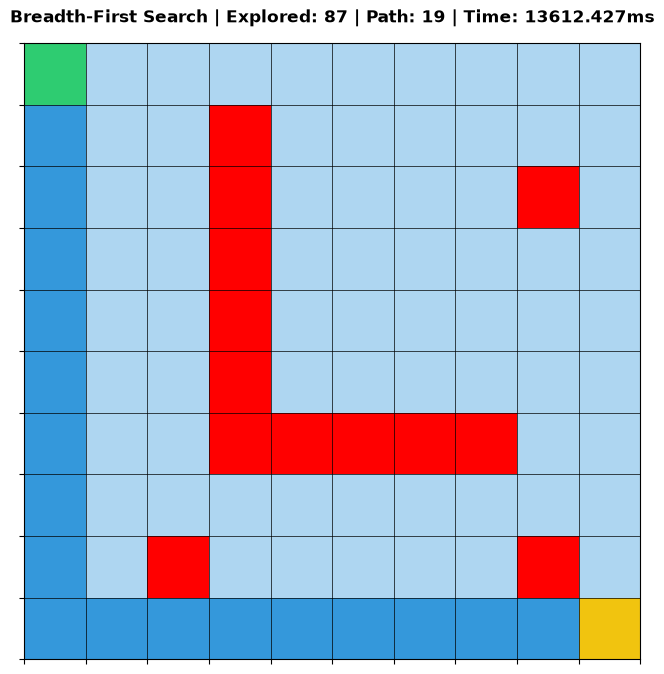

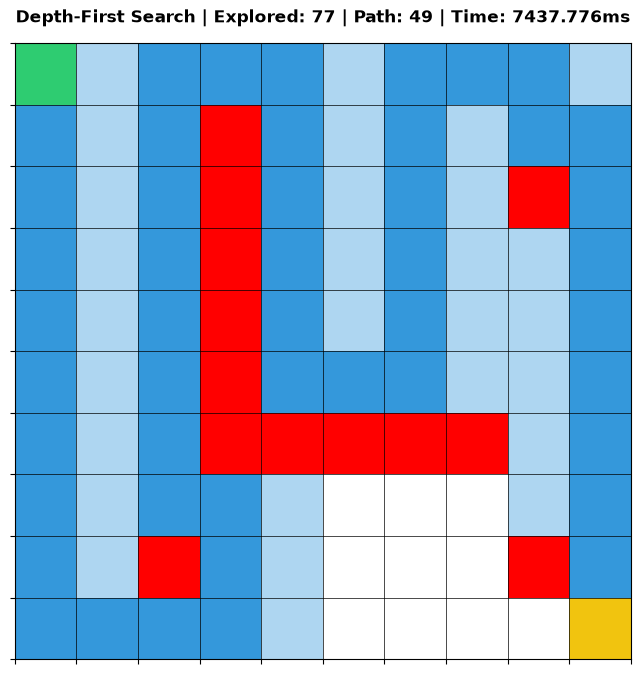

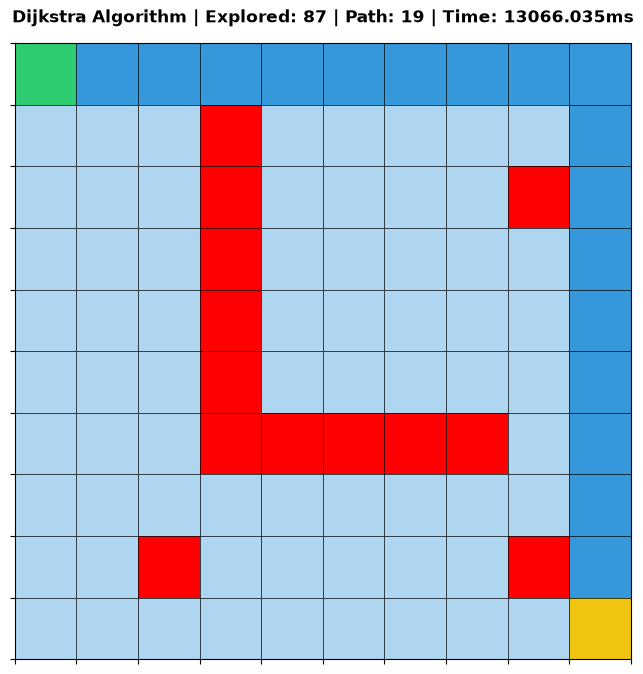

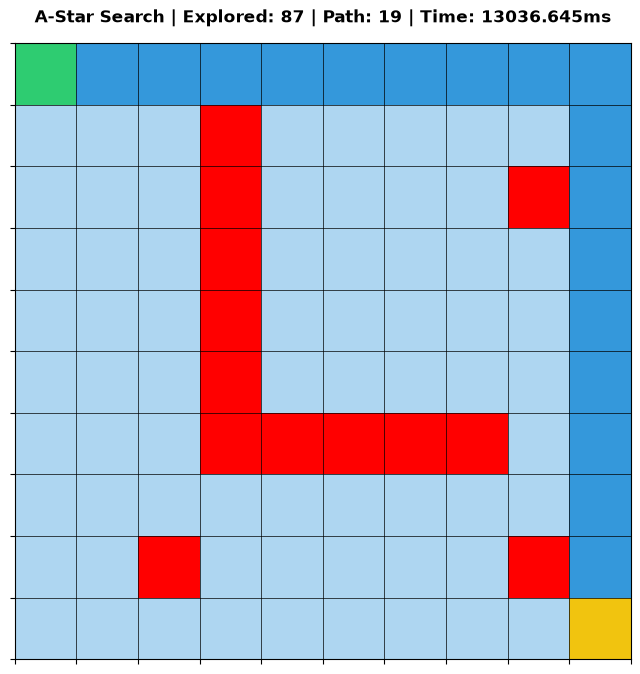

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import ipywidgets as widgets
from IPython.display import display, clear_output

# Import ALL algorithms and grid parser directly from Person A's algorithms.py
from algorithms import bfs, dfs, dijkstra, astar, load_grid

# ==========================================
# VISUAL CONFIGURATION
# ==========================================
EMPTY = 0
WALL = 1
START = 2
GOAL = 3
VISITED = 4
FRONTIER = 5
PATH = 6

# Colors: White(Empty), Red(Wall), Green(Start), Gold(Goal), Light Blue(Visited), Orange(Frontier), Blue(Path)
colors = ['#FFFFFF', '#FF0000', '#2ECC71', '#F1C40F', '#AED6F1', '#E67E22', '#3498DB']
cmap = ListedColormap(colors)


# ==========================================
# ANIMATION ENGINE
# ==========================================
def animate_algorithm(grid, generator, speed):
    """Consumes the algorithm generator, updates the plot, and returns final metrics."""
    n = grid.shape[0]
    final_metrics = None

    plot_output = widgets.Output()
    display(plot_output)

    with plot_output:
        fig, ax = plt.subplots(figsize=(8, 8))

    for state in generator:
        vis_grid = np.copy(grid)

        # Draw visited nodes
        for r, c in state['visited']:
            if vis_grid[r, c] not in [START, GOAL]:
                vis_grid[r, c] = VISITED

        # Draw frontier nodes
        for r, c in state.get('frontier', []):
            if vis_grid[r, c] not in [START, GOAL]:
                vis_grid[r, c] = FRONTIER

        # Draw final path
        if state.get('path'):
            for r, c in state['path']:
                if vis_grid[r, c] not in [START, GOAL]:
                    vis_grid[r, c] = PATH

        with plot_output:
            clear_output(wait=True)
            ax.clear()
            ax.imshow(vis_grid, cmap=cmap, vmin=0, vmax=6)

            # Draw dynamic grid lines based on size N
            ax.grid(which='major', axis='both', linestyle='-', color='k', linewidth=0.5)
            ax.set_xticks(np.arange(-0.5, n, 1))
            ax.set_yticks(np.arange(-0.5, n, 1))
            ax.set_xticklabels([])
            ax.set_yticklabels([])

            # Display metrics on the final frame and capture them
            if 'metrics' in state:
                final_metrics = state['metrics']
                ax.set_title(
                    f"{final_metrics['algorithm_name']} | Explored: {final_metrics['nodes_explored']} | "
                    f"Path: {final_metrics['path_length']} | Time: {final_metrics['execution_time_ms']}ms",
                    fontsize=12, fontweight='bold', pad=15
                )

            display(fig)

        time.sleep(speed)
        
    return final_metrics


# ==========================================
# UI CONTROLS & EVENT HANDLING
# ==========================================
algo_dropdown = widgets.Dropdown(
    options=['Breadth-First Search', 'Depth-First Search', "Dijkstra's Algorithm", 'A* Search', 'Run All & Compare'],
    value='Breadth-First Search',
    description='Algorithm:',
    style={'description_width': 'initial'}
)

speed_slider = widgets.FloatSlider(
    value=0.05,
    min=0.01,
    max=0.5,
    step=0.02,
    description='Frame Delay (s):',
    style={'description_width': 'initial'}
)

run_button = widgets.Button(
    description='Run Visualization',
    button_style='success',
    icon='play'
)

dashboard_ui = widgets.HBox([algo_dropdown, speed_slider, run_button])


def on_run_clicked(b):
    clear_output(wait=True)
    display(dashboard_ui)

    # 1. Load grid using Person A's load_grid function
    try:
        grid = load_grid('input.txt')
        # Ensure Start and Goal are set visually on the grid
        grid[0, 0] = START
        grid[grid.shape[0]-1, grid.shape[1]-1] = GOAL
    except Exception as e:
        print(f"Error loading input.txt: {e}")
        return

    # 2. Handle selection logic
    selected_algo = algo_dropdown.value

    if selected_algo == 'Run All & Compare':
        results = []
        algorithms_to_test = [
            ('Breadth-First Search', bfs),
            ('Depth-First Search', dfs),
            ("Dijkstra's Algorithm", dijkstra),
            ('A* Search', astar)
        ]
        
        # Execute each algorithm sequentially
        for name, algo_func in algorithms_to_test:
            print(f"Executing {name}...")
            generator = algo_func(grid)
            metrics = animate_algorithm(grid, generator, speed_slider.value)
            if metrics:
                results.append(metrics)
                
        # Generate the comparison DataFrame
        if results:
            df = pd.DataFrame(results)
            
            # Format and reorder columns for a professional presentation
            df = df[['algorithm_name', 'path_found', 'path_length', 'nodes_explored', 'execution_time_ms']]
            df.columns = ['Algorithm', 'Path Found', 'Path Length (Steps)', 'Nodes Explored', 'Execution Time (ms)']
            
            print("\n" + "="*60)
            print(" ALGORITHM COMPARISON DASHBOARD")
            print("="*60)
            
            # Use Jupyter's native rich display for pandas
            display(df)
            
    else:
        # Run single selected algorithm
        if selected_algo == 'Breadth-First Search':
            generator = bfs(grid)
        elif selected_algo == 'Depth-First Search':
            generator = dfs(grid)
        elif selected_algo == "Dijkstra's Algorithm":
            generator = dijkstra(grid)
        elif selected_algo == 'A* Search':
            generator = astar(grid)
        else:
            print(f"Algorithm {selected_algo} not recognized.")
            return

        # Trigger the animation engine
        animate_algorithm(grid, generator, speed_slider.value)


# Bind click event
run_button.on_click(on_run_clicked)

# Render UI controls
display(dashboard_ui)